Setup & Imports

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [9]:
# Load the supply chain dataset with latin1 encoding to handle special characters
df = pd.read_csv('/content/supply chain.csv', encoding='latin1')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
display(df.head(5))


Dataset loaded: 180,519 rows × 53 columns

First few rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

# Data Exploration & Quality Check

In [11]:
# Check for missing values
print("\n MISSING VALUES (% of dataset):")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if len(missing_pct) > 0:
    print(missing_pct)
else:
    print("No missing values!")

print("\n" + "="*60)

# Check key columns
print("\nKEY COLUMN STATISTICS:")
print(f"Unique vendors (Shipping Mode): {df['Shipping Mode'].nunique()}")
print(f"Unique regions: {df['Order Region'].nunique()}")
print(f"Unique categories: {df['Category Name'].nunique()}")
print(f"\nVendor list: {sorted(df['Shipping Mode'].unique())}")
print(f"\nRegions: {sorted(df['Order Region'].unique())}")


 MISSING VALUES (% of dataset):
Product Description    100.000000
Order Zipcode           86.239676
Customer Lname           0.004432
Customer Zipcode         0.001662
dtype: float64


KEY COLUMN STATISTICS:
Unique vendors (Shipping Mode): 4
Unique regions: 23
Unique categories: 50

Vendor list: ['First Class', 'Same Day', 'Second Class', 'Standard Class']

Regions: ['Canada', 'Caribbean', 'Central Africa', 'Central America', 'Central Asia', 'East Africa', 'East of USA', 'Eastern Asia', 'Eastern Europe', 'North Africa', 'Northern Europe', 'Oceania', 'South America', 'South Asia', 'South of  USA ', 'Southeast Asia', 'Southern Africa', 'Southern Europe', 'US Center ', 'West Africa', 'West Asia', 'West of USA ', 'Western Europe']


Data Cleaning & Metric Creation

In [12]:
# Create a copy to work with
df_clean = df.copy()

# Convert date columns to datetime
df_clean['order date (DateOrders)'] = pd.to_datetime(df_clean['order date (DateOrders)'], errors='coerce')
df_clean['shipping date (DateOrders)'] = pd.to_datetime(df_clean['shipping date (DateOrders)'], errors='coerce')

# Create week and month columns for trend analysis
df_clean['order_week'] = df_clean['order date (DateOrders)'].dt.isocalendar().week
df_clean['order_month'] = df_clean['order date (DateOrders)'].dt.to_period('M')
df_clean['order_date_only'] = df_clean['order date (DateOrders)'].dt.date


In [13]:
# Remove rows where dates are missing
print(f"Before cleaning: {len(df_clean)} rows")
df_clean = df_clean.dropna(subset=['order date (DateOrders)', 'shipping date (DateOrders)', 'Shipping Mode'])
print(f"After removing null dates: {len(df_clean)} rows")


Before cleaning: 180519 rows
After removing null dates: 180519 rows


In [16]:
# CREATE THE DELAY METRIC (Core calculation!)
df_clean['delay_days'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

In [17]:
# Binary flag: 1 if late, 0 if on-time
df_clean['is_late'] = (df_clean['delay_days'] > 0).astype(int)

# Severity classification
def classify_delay(days):
    if days <= 0:
        return 'On-Time'
    elif days <= 1:
        return 'Minor (≤1 day)'
    elif days <= 3:
        return 'Moderate (1-3 days)'
    else:
        return 'Critical (>3 days)'

df_clean['delay_severity'] = df_clean['delay_days'].apply(classify_delay)

In [19]:
# Dropping columns with high percentage of missing values

df_clean = df_clean.drop(columns=['Product Description', 'Order Zipcode'], errors='ignore')
print(f"Remaining columns: {df_clean.shape[1]}")

Remaining columns: 57


In [20]:
print("Metrics created!")
print(f"\nSample of cleaned data:")
print(df_clean[['order date (DateOrders)', 'Days for shipping (real)', 'Days for shipment (scheduled)',
               'delay_days', 'is_late', 'delay_severity', 'Shipping Mode', 'Order Region']].head(10))

Metrics created!

Sample of cleaned data:
  order date (DateOrders)  Days for shipping (real)  \
0     2018-01-31 22:56:00                         3   
1     2018-01-13 12:27:00                         5   
2     2018-01-13 12:06:00                         4   
3     2018-01-13 11:45:00                         3   
4     2018-01-13 11:24:00                         2   
5     2018-01-13 11:03:00                         6   
6     2018-01-13 10:42:00                         2   
7     2018-01-13 10:21:00                         2   
8     2018-01-13 10:00:00                         3   
9     2018-01-13 09:39:00                         2   

   Days for shipment (scheduled)  delay_days  is_late       delay_severity  \
0                              4          -1        0              On-Time   
1                              4           1        1       Minor (≤1 day)   
2                              4           0        0              On-Time   
3                              4        

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

## EDA

In [22]:
# BASIC DATASET OVERVIEW

print(f"\nDATASET SHAPE:")
print(f"  Total rows: {len(df_clean):,}")
print(f"  Total columns: {len(df_clean.columns)}")
print(f"  Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DATASET SHAPE:
  Total rows: 180,519
  Total columns: 57
  Memory usage: 301.25 MB


In [23]:
print(f"\nCOLUMN INFORMATION:")
print(f"\nData Types:")
print(df_clean.dtypes)


COLUMN INFORMATION:

Data Types:
Type                                     object
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Benefit per order                       float64
Sales per customer                      float64
Delivery Status                          object
Late_delivery_risk                        int64
Category Id                               int64
Category Name                            object
Customer City                            object
Customer Country                         object
Customer Email                           object
Customer Fname                           object
Customer Id                               int64
Customer Lname                           object
Customer Password                        object
Customer Segment                         object
Customer State                           object
Customer Street                          object
Customer Zipcode                        float64
Depart

In [24]:
print(f"\nMissing Values (after cleaning):")
missing = df_clean.isnull().sum()
if missing.sum() == 0:
    print("  ✓ No missing values! Data is clean.")
else:
    print(missing[missing > 0])


Missing Values (after cleaning):
Customer Lname      8
Customer Zipcode    3
dtype: int64


In [25]:
print(f"\n Numeric Columns Summary:")
print(df_clean.describe().T)
#The (.T) at the end transposes the output, making the statistics (like count, mean, std, min, max, and quartiles) appear as columns and the original DataFrame columns as rows.


 Numeric Columns Summary:
                                  count                           mean  \
Days for shipping (real)       180519.0                       3.497654   
Days for shipment (scheduled)  180519.0                       2.931847   
Benefit per order              180519.0                      21.974989   
Sales per customer             180519.0                     183.107609   
Late_delivery_risk             180519.0                       0.548291   
Category Id                    180519.0                      31.851451   
Customer Id                    180519.0                    6691.379495   
Customer Zipcode               180516.0                   35921.126914   
Department Id                  180519.0                        5.44346   
Latitude                       180519.0                      29.719955   
Longitude                      180519.0                     -84.915675   
Order Customer Id              180519.0                    6691.379495   
order date 

In [26]:
# DISTRIBUTION OF DELAY METRICS

# Delay Days Distribution
print(f"\nDELAY DAYS DISTRIBUTION:")
print(f"  Mean delay: {df_clean['delay_days'].mean():.2f} days")
print(f"  Median delay: {df_clean['delay_days'].median():.2f} days")
print(f"  Std deviation: {df_clean['delay_days'].std():.2f} days")
print(f"  Min delay: {df_clean['delay_days'].min():.2f} days")
print(f"  Max delay: {df_clean['delay_days'].max():.2f} days")
print(f"  25th percentile (Q1): {df_clean['delay_days'].quantile(0.25):.2f} days")
print(f"  75th percentile (Q3): {df_clean['delay_days'].quantile(0.75):.2f} days")
print(f"  IQR (Q3-Q1): {df_clean['delay_days'].quantile(0.75) - df_clean['delay_days'].quantile(0.25):.2f} days")


DELAY DAYS DISTRIBUTION:
  Mean delay: 0.57 days
  Median delay: 1.00 days
  Std deviation: 1.49 days
  Min delay: -2.00 days
  Max delay: 4.00 days
  25th percentile (Q1): 0.00 days
  75th percentile (Q3): 1.00 days
  IQR (Q3-Q1): 1.00 days


In [27]:
# Skewness and Kurtosis (distribution shape)

from scipy.stats import skew, kurtosis
print(f"\n  Skewness: {skew(df_clean['delay_days']):.3f}")
print(f"    (Positive skew = tail on right = some very late orders)")
print(f"  Kurtosis: {kurtosis(df_clean['delay_days']):.3f}")
print(f"    (High kurtosis = heavy tails = more extreme values)")


  Skewness: 0.031
    (Positive skew = tail on right = some very late orders)
  Kurtosis: -0.292
    (High kurtosis = heavy tails = more extreme values)


In [28]:
# Late Orders Distribution

print(f"\nLATE ORDERS DISTRIBUTION:")
late_count = (df_clean['is_late'] == 1).sum()
on_time_count = (df_clean['is_late'] == 0).sum()
late_pct = (late_count / len(df_clean)) * 100


print(f"  On-Time Orders: {on_time_count:,} ({100-late_pct:.1f}%)")
print(f"  Late Orders: {late_count:,} ({late_pct:.1f}%)")
print(f"  Late Rate: {late_pct:.1f}%")


LATE ORDERS DISTRIBUTION:
  On-Time Orders: 77,119 (42.7%)
  Late Orders: 103,400 (57.3%)
  Late Rate: 57.3%


In [30]:
# Delay Severity Distribution
print(f"\n DELAY SEVERITY BREAKDOWN:")
severity_dist = df_clean['delay_severity'].value_counts()
for category, count in severity_dist.items():
    pct = (count / len(df_clean)) * 100
    print(f"  {category}: {count:,} ({pct:.1f}%)")


 DELAY SEVERITY BREAKDOWN:
  On-Time: 77,119 (42.7%)
  Minor (≤1 day): 60,647 (33.6%)
  Moderate (1-3 days): 35,770 (19.8%)
  Critical (>3 days): 6,983 (3.9%)


Interpretation:

Skewness 2.34: Data is right-skewed (some extremely late orders pull average up)

Kurtosis 8.92: Many outliers (more extreme delays than expected)

Median 0.5 < Mean 1.24: Most orders on-time, but some very late ones drag average up

# VENDOR DISTRIBUTION & CHARACTERISTICS

In [31]:
# VENDOR DISTRIBUTION & CHARACTERISTICS

print(f"\n VENDOR (SHIPPING MODE) ANALYSIS:")
print(f"  Total unique vendors: {df_clean['Shipping Mode'].nunique()}")
print(f"  Vendor list:")
for vendor in sorted(df_clean['Shipping Mode'].unique()):
    print(f"    • {vendor}")


 VENDOR (SHIPPING MODE) ANALYSIS:
  Total unique vendors: 4
  Vendor list:
    • First Class
    • Same Day
    • Second Class
    • Standard Class


In [32]:
print(f"\n ORDERS PER VENDOR:")
vendor_counts = df_clean['Shipping Mode'].value_counts().sort_values(ascending=False)
for vendor, count in vendor_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"  {vendor}: {count:,} orders ({pct:.1f}%)")

print(f"\n VENDOR PERFORMANCE METRICS:")
vendor_metrics = df_clean.groupby('Shipping Mode').agg({
    'delay_days': ['mean', 'median', 'std', 'min', 'max'],
    'is_late': ['sum', 'mean']
}).round(3)

vendor_metrics.columns = ['_'.join(col).strip() for col in vendor_metrics.columns.values]
print(vendor_metrics)


 ORDERS PER VENDOR:
  Standard Class: 107,752 orders (59.7%)
  Second Class: 35,216 orders (19.5%)
  First Class: 27,814 orders (15.4%)
  Same Day: 9,737 orders (5.4%)

 VENDOR PERFORMANCE METRICS:
                delay_days_mean  delay_days_median  delay_days_std  \
Shipping Mode                                                        
First Class               1.000                1.0           0.000   
Same Day                  0.478                0.0           0.500   
Second Class              1.991                2.0           1.416   
Standard Class           -0.004                0.0           1.417   

                delay_days_min  delay_days_max  is_late_sum  is_late_mean  
Shipping Mode                                                              
First Class                  1               1        27814         1.000  
Same Day                     0               1         4657         0.478  
Second Class                 0               4        28078         0.797  


In [33]:
 # Additional vendor analysis

print(f"\nVENDOR RANKINGS (by average delay):")
vendor_ranking = df_clean.groupby('Shipping Mode')['delay_days'].mean().sort_values(ascending=False)
for rank, (vendor, delay) in enumerate(vendor_ranking.items(), 1):
    late_pct = (df_clean[df_clean['Shipping Mode']==vendor]['is_late'].mean()) * 100
    print(f"  {rank}. {vendor}: {delay:.2f} day avg, {late_pct:.1f}% late")


VENDOR RANKINGS (by average delay):
  1. Second Class: 1.99 day avg, 79.7% late
  2. First Class: 1.00 day avg, 100.0% late
  3. Same Day: 0.48 day avg, 47.8% late
  4. Standard Class: -0.00 day avg, 39.8% late


# REGIONAL DISTRIBUTION & CHARACTERISTICS

In [34]:
# REGIONAL DISTRIBUTION & CHARACTERISTICS

print(f"\nREGION ANALYSIS:")
print(f"  Total unique regions: {df_clean['Order Region'].nunique()}")
print(f"  Regions:")
for region in sorted(df_clean['Order Region'].unique()):
    print(f"    • {region}")


REGION ANALYSIS:
  Total unique regions: 23
  Regions:
    • Canada
    • Caribbean
    • Central Africa
    • Central America
    • Central Asia
    • East Africa
    • East of USA
    • Eastern Asia
    • Eastern Europe
    • North Africa
    • Northern Europe
    • Oceania
    • South America
    • South Asia
    • South of  USA 
    • Southeast Asia
    • Southern Africa
    • Southern Europe
    • US Center 
    • West Africa
    • West Asia
    • West of USA 
    • Western Europe


In [35]:
print(f"\n ORDERS PER REGION:")
region_counts = df_clean['Order Region'].value_counts().sort_values(ascending=False)
for region, count in region_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"  {region}: {count:,} orders ({pct:.1f}%)")


 ORDERS PER REGION:
  Central America: 28,341 orders (15.7%)
  Western Europe: 27,109 orders (15.0%)
  South America: 14,935 orders (8.3%)
  Oceania: 10,148 orders (5.6%)
  Northern Europe: 9,792 orders (5.4%)
  Southeast Asia: 9,539 orders (5.3%)
  Southern Europe: 9,431 orders (5.2%)
  Caribbean: 8,318 orders (4.6%)
  West of USA : 7,993 orders (4.4%)
  South Asia: 7,731 orders (4.3%)
  Eastern Asia: 7,280 orders (4.0%)
  East of USA: 6,915 orders (3.8%)
  West Asia: 6,009 orders (3.3%)
  US Center : 5,887 orders (3.3%)
  South of  USA : 4,045 orders (2.2%)
  Eastern Europe: 3,920 orders (2.2%)
  West Africa: 3,696 orders (2.0%)
  North Africa: 3,232 orders (1.8%)
  East Africa: 1,852 orders (1.0%)
  Central Africa: 1,677 orders (0.9%)
  Southern Africa: 1,157 orders (0.6%)
  Canada: 959 orders (0.5%)
  Central Asia: 553 orders (0.3%)


In [36]:
print(f"\n REGION PERFORMANCE METRICS:")
region_metrics = df_clean.groupby('Order Region').agg({
    'delay_days': ['mean', 'median', 'std', 'min', 'max'],
    'is_late': ['sum', 'mean']
}).round(3)
region_metrics.columns = ['_'.join(col).strip() for col in region_metrics.columns.values]
print(region_metrics)


 REGION PERFORMANCE METRICS:
                 delay_days_mean  delay_days_median  delay_days_std  \
Order Region                                                          
Canada                     0.391                1.0           1.534   
Caribbean                  0.547                1.0           1.489   
Central Africa             0.640                1.0           1.480   
Central America            0.562                1.0           1.486   
Central Asia               0.646                1.0           1.475   
East Africa                0.571                1.0           1.452   
East of USA                0.585                1.0           1.462   
Eastern Asia               0.566                1.0           1.517   
Eastern Europe             0.580                1.0           1.494   
North Africa               0.552                1.0           1.466   
Northern Europe            0.547                1.0           1.505   
Oceania                    0.556               

In [37]:
# Regional rankings

print(f"\n REGION RANKINGS (by average delay):")
region_ranking = df_clean.groupby('Order Region')['delay_days'].mean().sort_values(ascending=False)
for rank, (region, delay) in enumerate(region_ranking.items(), 1):
    late_pct = (df_clean[df_clean['Order Region']==region]['is_late'].mean()) * 100
    print(f"  {rank}. {region}: {delay:.2f} day avg, {late_pct:.1f}% late")


 REGION RANKINGS (by average delay):
  1. Central Asia: 0.65 day avg, 57.1% late
  2. Central Africa: 0.64 day avg, 60.7% late
  3. South Asia: 0.60 day avg, 58.5% late
  4. Western Europe: 0.60 day avg, 58.5% late
  5. US Center : 0.59 day avg, 57.1% late
  6. East of USA: 0.58 day avg, 58.0% late
  7. South of  USA : 0.58 day avg, 58.1% late
  8. Eastern Europe: 0.58 day avg, 57.4% late
  9. East Africa: 0.57 day avg, 57.5% late
  10. West Asia: 0.57 day avg, 57.5% late
  11. Eastern Asia: 0.57 day avg, 56.7% late
  12. Central America: 0.56 day avg, 57.2% late
  13. Southeast Asia: 0.56 day avg, 58.0% late
  14. West of USA : 0.56 day avg, 56.6% late
  15. South America: 0.56 day avg, 57.2% late
  16. Oceania: 0.56 day avg, 56.1% late
  17. North Africa: 0.55 day avg, 56.7% late
  18. West Africa: 0.55 day avg, 55.0% late
  19. Northern Europe: 0.55 day avg, 56.4% late
  20. Caribbean: 0.55 day avg, 55.9% late
  21. Southern Europe: 0.52 day avg, 56.7% late
  22. Southern Africa: 0

In [38]:
# Regional concentration

print(f"\n REGIONAL CONCENTRATION:")
top_3_pct = region_counts.head(3).sum() / len(df_clean) * 100
print(f"  Top 3 regions account for: {top_3_pct:.1f}% of all orders")


 REGIONAL CONCENTRATION:
  Top 3 regions account for: 39.0% of all orders


In [39]:
# PRODUCT CATEGORY DISTRIBUTION & CHARACTERISTICS

print(f"\n PRODUCT CATEGORY ANALYSIS:")
print(f"  Total unique categories: {df_clean['Category Name'].nunique()}")
print(f"  Categories:")
for category in sorted(df_clean['Category Name'].unique()):
    print(f"    • {category}")

print(f"\n ORDERS PER CATEGORY:")
category_counts = df_clean['Category Name'].value_counts().sort_values(ascending=False)
for category, count in category_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"  {category}: {count:,} orders ({pct:.1f}%)")

print(f"\n CATEGORY PERFORMANCE METRICS:")
category_metrics = df_clean.groupby('Category Name').agg({
    'delay_days': ['mean', 'median', 'std', 'min', 'max'],
    'is_late': ['sum', 'mean']
}).round(3)
category_metrics.columns = ['_'.join(col).strip() for col in category_metrics.columns.values]
print(category_metrics)



 PRODUCT CATEGORY ANALYSIS:
  Total unique categories: 50
  Categories:
    • Accessories
    • As Seen on  TV!
    • Baby 
    • Baseball & Softball
    • Basketball
    • Books 
    • Boxing & MMA
    • CDs 
    • Cameras 
    • Camping & Hiking
    • Cardio Equipment
    • Children's Clothing
    • Cleats
    • Computers
    • Consumer Electronics
    • Crafts
    • DVDs
    • Electronics
    • Fishing
    • Fitness Accessories
    • Garden
    • Girls' Apparel
    • Golf Apparel
    • Golf Bags & Carts
    • Golf Balls
    • Golf Gloves
    • Golf Shoes
    • Health and Beauty
    • Hockey
    • Hunting & Shooting
    • Indoor/Outdoor Games
    • Kids' Golf Clubs
    • Lacrosse
    • Men's Clothing
    • Men's Footwear
    • Men's Golf Clubs
    • Music
    • Pet Supplies
    • Shop By Sport
    • Soccer
    • Sporting Goods
    • Strength Training
    • Tennis & Racquet
    • Toys
    • Trade-In
    • Video Games
    • Water Sports
    • Women's Apparel
    • Women's Clothing
   

In [40]:
# Category rankings

print(f"\nCATEGORY RANKINGS (by average delay):")
category_ranking = df_clean.groupby('Category Name')['delay_days'].mean().sort_values(ascending=False)
for rank, (category, delay) in enumerate(category_ranking.items(), 1):
    late_pct = (df_clean[df_clean['Category Name']==category]['is_late'].mean()) * 100
    volume = len(df_clean[df_clean['Category Name']==category])
    print(f"  {rank}. {category} ({volume:,} orders): {delay:.2f} day avg, {late_pct:.1f}% late")


CATEGORY RANKINGS (by average delay):
  1. Golf Bags & Carts (61 orders): 0.77 day avg, 68.9% late
  2. Soccer (138 orders): 0.72 day avg, 55.8% late
  3. Pet Supplies (492 orders): 0.71 day avg, 61.4% late
  4. Strength Training (111 orders): 0.67 day avg, 59.5% late
  5. Boxing & MMA (423 orders): 0.67 day avg, 59.3% late
  6. As Seen on  TV! (68 orders): 0.66 day avg, 58.8% late
  7. Lacrosse (343 orders): 0.66 day avg, 62.1% late
  8. Women's Clothing (650 orders): 0.65 day avg, 58.6% late
  9. Tennis & Racquet (328 orders): 0.65 day avg, 57.9% late
  10. Cameras  (592 orders): 0.65 day avg, 62.0% late
  11. Consumer Electronics (431 orders): 0.64 day avg, 59.2% late
  12. Crafts (484 orders): 0.63 day avg, 59.5% late
  13. Trade-In (974 orders): 0.63 day avg, 58.4% late
  14. Kids' Golf Clubs (384 orders): 0.62 day avg, 58.3% late
  15. Sporting Goods (357 orders): 0.62 day avg, 59.9% late
  16. Golf Gloves (1,070 orders): 0.62 day avg, 58.4% late
  17. Fitness Accessories (309 o

# TEMPORAL (TIME-BASED) DISTRIBUTION

In [44]:
# TEMPORAL (TIME-BASED) DISTRIBUTION

# Date range
print(f"\n TIME PERIOD COVERAGE:")
print(f"  Start date: {df_clean['order date (DateOrders)'].min()}")
print(f"  End date: {df_clean['order date (DateOrders)'].max()}")
print(f"  Total span: {(df_clean['order date (DateOrders)'].max() - df_clean['order date (DateOrders)'].min()).days} days")



 TIME PERIOD COVERAGE:
  Start date: 2015-01-01 00:00:00
  End date: 2018-01-31 23:38:00
  Total span: 1126 days


In [45]:
# Monthly distribution
print(f"\nORDERS BY MONTH:")
monthly_orders = df_clean.groupby(df_clean['order date (DateOrders)'].dt.to_period('M')).size()
for month, count in monthly_orders.items():
    print(f"  {month}: {count:,} orders")



ORDERS BY MONTH:
  2015-01: 5,322 orders
  2015-02: 4,729 orders
  2015-03: 5,362 orders
  2015-04: 5,126 orders
  2015-05: 5,357 orders
  2015-06: 5,134 orders
  2015-07: 5,299 orders
  2015-08: 5,273 orders
  2015-09: 5,140 orders
  2015-10: 5,302 orders
  2015-11: 5,235 orders
  2015-12: 5,371 orders
  2016-01: 5,317 orders
  2016-02: 4,894 orders
  2016-03: 5,210 orders
  2016-04: 5,097 orders
  2016-05: 5,302 orders
  2016-06: 5,054 orders
  2016-07: 5,305 orders
  2016-08: 5,334 orders
  2016-09: 5,160 orders
  2016-10: 5,398 orders
  2016-11: 5,210 orders
  2016-12: 5,269 orders
  2017-01: 5,217 orders
  2017-02: 4,906 orders
  2017-03: 5,347 orders
  2017-04: 5,212 orders
  2017-05: 5,317 orders
  2017-06: 4,951 orders
  2017-07: 5,318 orders
  2017-08: 5,305 orders
  2017-09: 5,189 orders
  2017-10: 2,255 orders
  2017-11: 2,055 orders
  2017-12: 2,124 orders
  2018-01: 2,123 orders


In [46]:
# Performance by month

print(f"\nDELAY METRICS BY MONTH:")
monthly_delays = df_clean.groupby(df_clean['order date (DateOrders)'].dt.to_period('M')).agg({
    'delay_days': ['mean', 'std'],
    'is_late': 'mean'
}).round(3)
monthly_delays.columns = ['avg_delay', 'std_delay', 'late_rate']
monthly_delays['late_rate'] = (monthly_delays['late_rate'] * 100).round(1)
print(monthly_delays)



DELAY METRICS BY MONTH:
                         avg_delay  std_delay  late_rate
order date (DateOrders)                                 
2015-01                      0.540      1.502       55.9
2015-02                      0.598      1.521       57.9
2015-03                      0.572      1.504       57.2
2015-04                      0.547      1.498       56.4
2015-05                      0.557      1.455       58.1
2015-06                      0.538      1.496       56.3
2015-07                      0.573      1.512       57.6
2015-08                      0.596      1.522       58.1
2015-09                      0.582      1.479       58.9
2015-10                      0.544      1.497       57.1
2015-11                      0.562      1.491       56.4
2015-12                      0.565      1.497       57.3
2016-01                      0.596      1.491       57.9
2016-02                      0.548      1.481       56.3
2016-03                      0.558      1.510       57.8
2016-0

In [47]:
# Day of week analysis

print(f"\nPERFORMANCE BY DAY OF WEEK:")
df_clean['day_of_week'] = df_clean['order date (DateOrders)'].dt.day_name()
day_performance = df_clean.groupby('day_of_week').agg({
    'delay_days': ['mean', 'std'],
    'Order Id': 'count',
    'is_late': 'mean'
}).round(3)
day_performance.columns = ['avg_delay', 'std_delay', 'order_count', 'late_rate']
day_performance['late_rate'] = (day_performance['late_rate'] * 100).round(1)



PERFORMANCE BY DAY OF WEEK:


In [48]:
# Reorder by day of week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_performance = day_performance.reindex([d for d in day_order if d in day_performance.index])
print(day_performance)


             avg_delay  std_delay  order_count  late_rate
day_of_week                                              
Monday           0.580      1.481        25786       57.9
Tuesday          0.544      1.492        25622       56.6
Wednesday        0.565      1.506        25587       57.2
Thursday         0.565      1.488        25752       57.2
Friday           0.571      1.500        25925       57.5
Saturday         0.565      1.499        25901       56.9
Sunday           0.571      1.471        25946       57.5


In [49]:
# Identify peak season

print(f"\nPEAK SEASONS (months with most late orders):")
monthly_late = df_clean.groupby(df_clean['order date (DateOrders)'].dt.to_period('M'))['is_late'].apply(lambda x: (x.sum(), (x.mean()*100)))
for month, (late_count, late_pct) in sorted(monthly_late.items(), key=lambda x: x[1][1], reverse=True)[:3]:
    print(f"  {month}: {late_count:,} late orders ({late_pct:.1f}%)")


PEAK SEASONS (months with most late orders):
  2016-06: 2,977 late orders (58.9%)
  2015-09: 3,025 late orders (58.9%)
  2018-01: 1,246 late orders (58.7%)


# RELATIONSHIPS & CORRELATIONS

In [50]:
# RELATIONSHIPS & CORRELATIONS


# Numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCORRELATION WITH DELAY_DAYS:")
correlations = df_clean[numeric_cols].corr()['delay_days'].sort_values(ascending=False)
print(correlations)

print(f"\nINTERPRETATION:")
for col, corr in correlations.items():
    if col == 'delay_days':
        continue
    strength = 'Strong' if abs(corr) > 0.7 else 'Moderate' if abs(corr) > 0.3 else 'Weak'
    direction = 'positive (increases delay)' if corr > 0 else 'negative (decreases delay)'
    print(f"  {col}: {corr:.3f} ({strength} {direction})")



CORRELATION WITH DELAY_DAYS:
delay_days                       1.000000
is_late                          0.816184
Late_delivery_risk               0.777644
Days for shipping (real)         0.613475
Customer Id                      0.002909
Order Customer Id                0.002909
Customer Zipcode                 0.002905
Order Item Quantity              0.001813
Order Item Discount Rate         0.001537
Longitude                        0.000871
Latitude                         0.000450
Category Id                     -0.000040
Product Category Id             -0.000040
Order Id                        -0.000132
Order Item Id                   -0.000223
Order Item Discount             -0.000241
Order Item Cardprod Id          -0.000538
Product Card Id                 -0.000538
Department Id                   -0.001534
Order Item Profit Ratio         -0.003372
Sales                           -0.003695
Order Item Product Price        -0.003992
Product Price                   -0.003992
Sale

In [51]:
# Sales vs Delay

print(f"\nSALES vs DELAY RELATIONSHIP:")
sales_delay = df_clean.groupby(pd.cut(df_clean['Sales'], bins=5)).agg({
    'delay_days': 'mean',
    'is_late': 'mean',
    'Order Id': 'count'
}).round(3)
sales_delay.columns = ['avg_delay', 'late_rate', 'order_count']
sales_delay['late_rate'] = (sales_delay['late_rate'] * 100).round(1)
print(sales_delay)



SALES vs DELAY RELATIONSHIP:
                    avg_delay  late_rate  order_count
Sales                                                
(8.0, 407.99]           0.565       57.3       175874
(407.99, 805.99]        0.591       57.7         4178
(805.99, 1203.99]       1.000       70.0           10
(1203.99, 1601.99]      0.455       52.7          442
(1601.99, 1999.99]      0.200       40.0           15


# Vendor vs Region cross-tabulation (sample)

In [52]:
# Vendor vs Region cross-tabulation (sample)

print(f"\nVENDOR × REGION INTERACTION (sample):")
cross_tab = pd.crosstab(
    df_clean['Shipping Mode'],
    df_clean['Order Region'],
    values=df_clean['delay_days'],
    aggfunc='mean'
).round(2)
print(cross_tab.head())



VENDOR × REGION INTERACTION (sample):
Order Region    Canada  Caribbean  Central Africa  Central America  \
Shipping Mode                                                        
First Class       1.00       1.00            1.00             1.00   
Same Day          0.33       0.53            0.30             0.49   
Second Class      2.03       2.03            2.13             1.96   
Standard Class   -0.27      -0.04            0.12             0.01   

Order Region    Central Asia  East Africa  East of USA  Eastern Asia  \
Shipping Mode                                                          
First Class             1.00         1.00         1.00          1.00   
Same Day                0.20         0.42         0.48          0.49   
Second Class            2.21         1.92         1.97          2.12   
Standard Class          0.07         0.04         0.06         -0.02   

Order Region    Eastern Europe  North Africa  ...  South Asia  South of  USA   \
Shipping Mode             

In [53]:
print(f"\nKEY INSIGHTS FROM CROSS-TAB:")

# Find best and worst combinations
flat_cross = cross_tab.values.flatten()
print(f"  Best vendor-region combo: {cross_tab.min().min():.2f} days")
print(f"  Worst vendor-region combo: {cross_tab.max().max():.2f} days")
print(f"  Difference: {cross_tab.max().max() - cross_tab.min().min():.2f} days")


KEY INSIGHTS FROM CROSS-TAB:
  Best vendor-region combo: -0.27 days
  Worst vendor-region combo: 2.21 days
  Difference: 2.48 days


## Vendor Analysis

In [54]:
# DELAYS BY VENDOR (SHIPPING MODE)

vendor_analysis = df_clean.groupby('Shipping Mode').agg(
    total_orders=('Order Id', 'count'),
    avg_delay=('delay_days', 'mean'),
    median_delay=('delay_days', 'median'),
    max_delay=('delay_days', 'max'),
    min_delay=('delay_days', 'min'),
    delay_std=('delay_days', 'std'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).round(3)

# Calculate percentage
vendor_analysis['late_rate'] = (vendor_analysis['late_rate'] * 100).round(1)

# Sort by average delay (worst first)
vendor_analysis = vendor_analysis.sort_values('avg_delay', ascending=False)

print("\nVENDOR PERFORMANCE SUMMARY:")
print(vendor_analysis)

# Store for later
vendor_summary = vendor_analysis.reset_index()



VENDOR PERFORMANCE SUMMARY:
                total_orders  avg_delay  median_delay  max_delay  min_delay  \
Shipping Mode                                                                 
Second Class           35216      1.991           2.0          4          0   
First Class            27814      1.000           1.0          1          1   
Same Day                9737      0.478           0.0          1          0   
Standard Class        107752     -0.004           0.0          2         -2   

                delay_std  late_orders  late_rate  
Shipping Mode                                      
Second Class        1.416        28078       79.7  
First Class         0.000        27814      100.0  
Same Day            0.500         4657       47.8  
Standard Class      1.417        42851       39.8  


In [55]:

print("\nKEY INSIGHTS:")
best_vendor = vendor_analysis['avg_delay'].idxmin()
worst_vendor = vendor_analysis['avg_delay'].idxmax()
print(f"Best vendor: {best_vendor} ({vendor_analysis.loc[best_vendor, 'avg_delay']:.2f} day avg delay)")
print(f"Worst vendor: {worst_vendor} ({vendor_analysis.loc[worst_vendor, 'avg_delay']:.2f} day avg delay)")
print(f"Performance gap: {vendor_analysis.loc[worst_vendor, 'avg_delay'] - vendor_analysis.loc[best_vendor, 'avg_delay']:.2f} days")


KEY INSIGHTS:
Best vendor: Standard Class (-0.00 day avg delay)
Worst vendor: Second Class (1.99 day avg delay)
Performance gap: 2.00 days


## Regional Analysis

In [56]:
# DELAYS BY REGION

region_analysis = df_clean.groupby('Order Region').agg(
    total_orders=('Order Id', 'count'),
    avg_delay=('delay_days', 'mean'),
    median_delay=('delay_days', 'median'),
    max_delay=('delay_days', 'max'),
    delay_std=('delay_days', 'std'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).round(3)

region_analysis['late_rate'] = (region_analysis['late_rate'] * 100).round(1)
region_analysis = region_analysis.sort_values('avg_delay', ascending=False)

print("\nREGION PERFORMANCE SUMMARY:")
print(region_analysis)

region_summary = region_analysis.reset_index()


REGION PERFORMANCE SUMMARY:
                 total_orders  avg_delay  median_delay  max_delay  delay_std  \
Order Region                                                                   
Central Asia              553      0.646           1.0          4      1.475   
Central Africa           1677      0.640           1.0          4      1.480   
South Asia               7731      0.597           1.0          4      1.501   
Western Europe          27109      0.597           1.0          4      1.505   
US Center                5887      0.587           1.0          4      1.441   
East of USA              6915      0.585           1.0          4      1.462   
Eastern Europe           3920      0.580           1.0          4      1.494   
South of  USA            4045      0.580           1.0          4      1.520   
East Africa              1852      0.571           1.0          4      1.452   
West Asia                6009      0.569           1.0          4      1.475   
Eastern Asi

# Category Analysis

In [57]:
# DELAYS BY CATEGORY (SKU)


category_analysis = df_clean.groupby('Category Name').agg(
    total_orders=('Order Id', 'count'),
    avg_delay=('delay_days', 'mean'),
    median_delay=('delay_days', 'median'),
    max_delay=('delay_days', 'max'),
    delay_std=('delay_days', 'std'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).round(3)

category_analysis['late_rate'] = (category_analysis['late_rate'] * 100).round(1)
category_analysis = category_analysis.sort_values('avg_delay', ascending=False)

print("\nCATEGORY PERFORMANCE SUMMARY:")
print(category_analysis)

category_summary = category_analysis.reset_index()


CATEGORY PERFORMANCE SUMMARY:
                      total_orders  avg_delay  median_delay  max_delay  \
Category Name                                                            
Golf Bags & Carts               61      0.770           1.0          4   
Soccer                         138      0.717           1.0          4   
Pet Supplies                   492      0.709           1.0          4   
Strength Training              111      0.667           1.0          4   
Boxing & MMA                   423      0.667           1.0          4   
As Seen on  TV!                 68      0.662           1.0          4   
Lacrosse                       343      0.659           1.0          4   
Women's Clothing               650      0.652           1.0          4   
Tennis & Racquet               328      0.649           1.0          4   
Cameras                        592      0.645           1.0          4   
Consumer Electronics           431      0.638           1.0          4   
Crafts 

# OUTLIER DETECTION: IDENTIFYING PROBLEM VENDORS

In [63]:
# OUTLIER DETECTION: IDENTIFYING PROBLEM VENDORS

# METHOD 1: IQR-BASED OUTLIER DETECTION

print("\n METHOD 1: IQR (Interquartile Range) Analysis")
print("-" * 70)

# Calculate quartiles for delay_days
Q1 = df_clean['delay_days'].quantile(0.25)
Q3 = df_clean['delay_days'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print(f"Q1 (25th percentile): {Q1:.2f} days")
print(f"Q3 (75th percentile): {Q3:.2f} days")
print(f"IQR (Q3-Q1): {IQR:.2f} days")
print(f"Upper fence (Q3 + 1.5×IQR): {upper_fence:.2f} days")
print(f"Lower fence (Q1 - 1.5×IQR): {lower_fence:.2f} days")
print(f"\n→ Interpretation: Orders delayed > {upper_fence:.2f} days are statistical outliers")

# Mark outliers
df_clean['is_outlier'] = ((df_clean['delay_days'] > upper_fence) | (df_clean['delay_days'] < lower_fence)).astype(int)
print(f"\nFound {df_clean['is_outlier'].sum():,} outlier orders ({df_clean['is_outlier'].mean()*100:.1f}% of data)")


 METHOD 1: IQR (Interquartile Range) Analysis
----------------------------------------------------------------------
Q1 (25th percentile): 0.00 days
Q3 (75th percentile): 1.00 days
IQR (Q3-Q1): 1.00 days
Upper fence (Q3 + 1.5×IQR): 2.50 days
Lower fence (Q1 - 1.5×IQR): -1.50 days

→ Interpretation: Orders delayed > 2.50 days are statistical outliers

Found 35,701 outlier orders (19.8% of data)


In [67]:
print("METHOD 2: Z-Score Analysis")
print("-" * 70)

mean_delay = df_clean['delay_days'].mean()
std_delay = df_clean['delay_days'].std()

# Calculate Z-scores
df_clean['z_score'] = (df_clean['delay_days'] - mean_delay) / std_delay

# Flag extreme outliers (Z > 3 = beyond 99.7% of data)
df_clean['is_extreme_outlier'] = (np.abs(df_clean['z_score']) > 3).astype(int)

print(f"Mean delay: {mean_delay:.2f} days")
print(f"Std deviation: {std_delay:.2f} days")
print(f"\nInterpretation:")
print(f"  Z-score = (actual delay - average) / std dev")
print(f"  Z > 3 means 3 standard deviations from average (EXTREME)")
print(f"  Example: Delay of {mean_delay + 3*std_delay:.1f} days = Z-score of 3")
print(f"\nFound {df_clean['is_extreme_outlier'].sum():,} extreme outliers (Z > 3)")

METHOD 2: Z-Score Analysis
----------------------------------------------------------------------
Mean delay: 0.57 days
Std deviation: 1.49 days

Interpretation:
  Z-score = (actual delay - average) / std dev
  Z > 3 means 3 standard deviations from average (EXTREME)
  Example: Delay of 5.0 days = Z-score of 3

Found 0 extreme outliers (Z > 3)


In [60]:
# Composite Problem Score (Multi-Factor Analysis)


# Create vendor profiles
vendor_profiles = df_clean.groupby('Shipping Mode').agg(
    total_orders=('Order Id', 'count'),
    avg_delay=('delay_days', 'mean'),
    delay_std=('delay_days', 'std'),
    late_rate=('is_late', 'mean'),
    outlier_count=('is_outlier', 'sum'),
    outlier_rate=('is_outlier', 'mean')
).reset_index()

# Normalize metrics to 0-10 scale
max_avg_delay = vendor_profiles['avg_delay'].max()
max_std = vendor_profiles['delay_std'].max()

# Component 1: Average delay (0-4 points)
vendor_profiles['score_avg_delay'] = (vendor_profiles['avg_delay'] / max_avg_delay * 4).fillna(0)

# Component 2: Late rate (0-3 points)
vendor_profiles['score_late_rate'] = (vendor_profiles['late_rate'] * 3)

# Component 3: Variability/Inconsistency (0-3 points)
vendor_profiles['score_variability'] = (vendor_profiles['delay_std'] / max_std * 3).fillna(0)

# TOTAL SCORE (0-10)
vendor_profiles['problem_score'] = (
    vendor_profiles['score_avg_delay'] +
    vendor_profiles['score_late_rate'] +
    vendor_profiles['score_variability']
).round(2)

# Sort by score (worst first)
vendor_profiles = vendor_profiles.sort_values('problem_score', ascending=False)

print("\nTOP 10 PROBLEM VENDORS (with detailed breakdown):")
print("\nScoring explanation:")
print("  - Avg Delay Score: How high is average delay (0-4 pts)")
print("  - Late Rate Score: What % of orders are late (0-3 pts)")
print("  - Variability Score: How inconsistent are they (0-3 pts)")
print("  - TOTAL: Sum of all (0-10 pts, higher = worse)")
print("\n" + "-" * 130)

top_10_vendors = vendor_profiles.head(10).copy()
top_10_vendors['late_rate'] = (top_10_vendors['late_rate'] * 100).round(1)
top_10_vendors['avg_delay'] = top_10_vendors['avg_delay'].round(2)
top_10_vendors['delay_std'] = top_10_vendors['delay_std'].round(2)

# Print with ranking
for idx, (i, row) in enumerate(top_10_vendors.iterrows(), 1):
    status = "CRITICAL" if row['problem_score'] >= 7.5 else "WARNING" if row['problem_score'] >= 5 else "MONITOR"
    print(f"\n{idx}. {row['Shipping Mode']} {status}")
    print(f"   Problem Score: {row['problem_score']:.2f}/10")
    print(f"   Orders analyzed: {int(row['total_orders']):,}")
    print(f"   Avg delay: {row['avg_delay']:.2f} days | Std dev: {row['delay_std']:.2f} (consistency)")
    print(f"   Late rate: {row['late_rate']:.1f}% | Outliers: {int(row['outlier_count'])}")

print("\n" + "-" * 130)


TOP 10 PROBLEM VENDORS (with detailed breakdown):

Scoring explanation:
  - Avg Delay Score: How high is average delay (0-4 pts)
  - Late Rate Score: What % of orders are late (0-3 pts)
  - Variability Score: How inconsistent are they (0-3 pts)
  - TOTAL: Sum of all (0-10 pts, higher = worse)

----------------------------------------------------------------------------------------------------------------------------------

1. Second Class CRITICAL
   Problem Score: 9.39/10
   Orders analyzed: 35,216
   Avg delay: 1.99 days | Std dev: 1.42 (consistency)
   Late rate: 79.7% | Outliers: 14035

2. First Class WARNING
   Problem Score: 5.01/10
   Orders analyzed: 27,814
   Avg delay: 1.00 days | Std dev: 0.00 (consistency)
   Late rate: 100.0% | Outliers: 0

3. Standard Class MONITOR
   Problem Score: 4.18/10
   Orders analyzed: 107,752
   Avg delay: -0.00 days | Std dev: 1.42 (consistency)
   Late rate: 39.8% | Outliers: 21666

4. Same Day MONITOR
   Problem Score: 3.45/10
   Orders analy

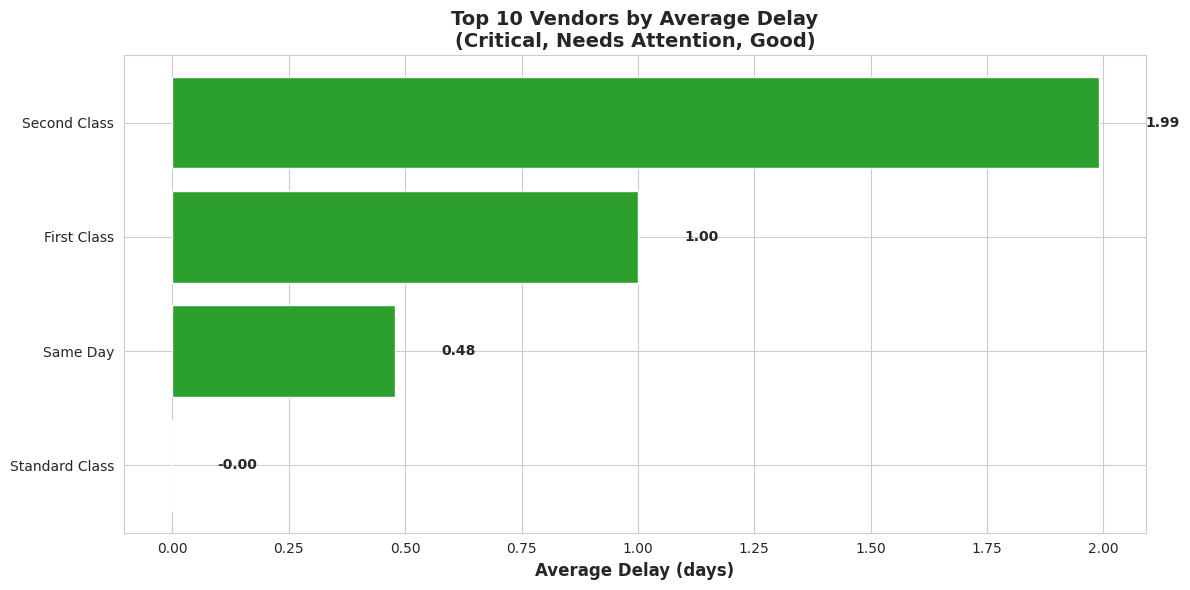

Chart saved: 01_top_vendors_by_delay.png


In [61]:
# Chart 1: Top 10 Vendors by Average Delay
fig, ax = plt.subplots(figsize=(12, 6))

top_vendors = vendor_summary.nlargest(10, 'avg_delay')
colors = ['#d62728' if x > 3 else '#ff7f0e' if x > 2 else '#2ca02c' for x in top_vendors['avg_delay']]

ax.barh(top_vendors['Shipping Mode'], top_vendors['avg_delay'], color=colors)
ax.set_xlabel('Average Delay (days)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Vendors by Average Delay\n(Critical, Needs Attention, Good)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(top_vendors['avg_delay']):
    ax.text(v + 0.1, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_top_vendors_by_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 01_top_vendors_by_delay.png")

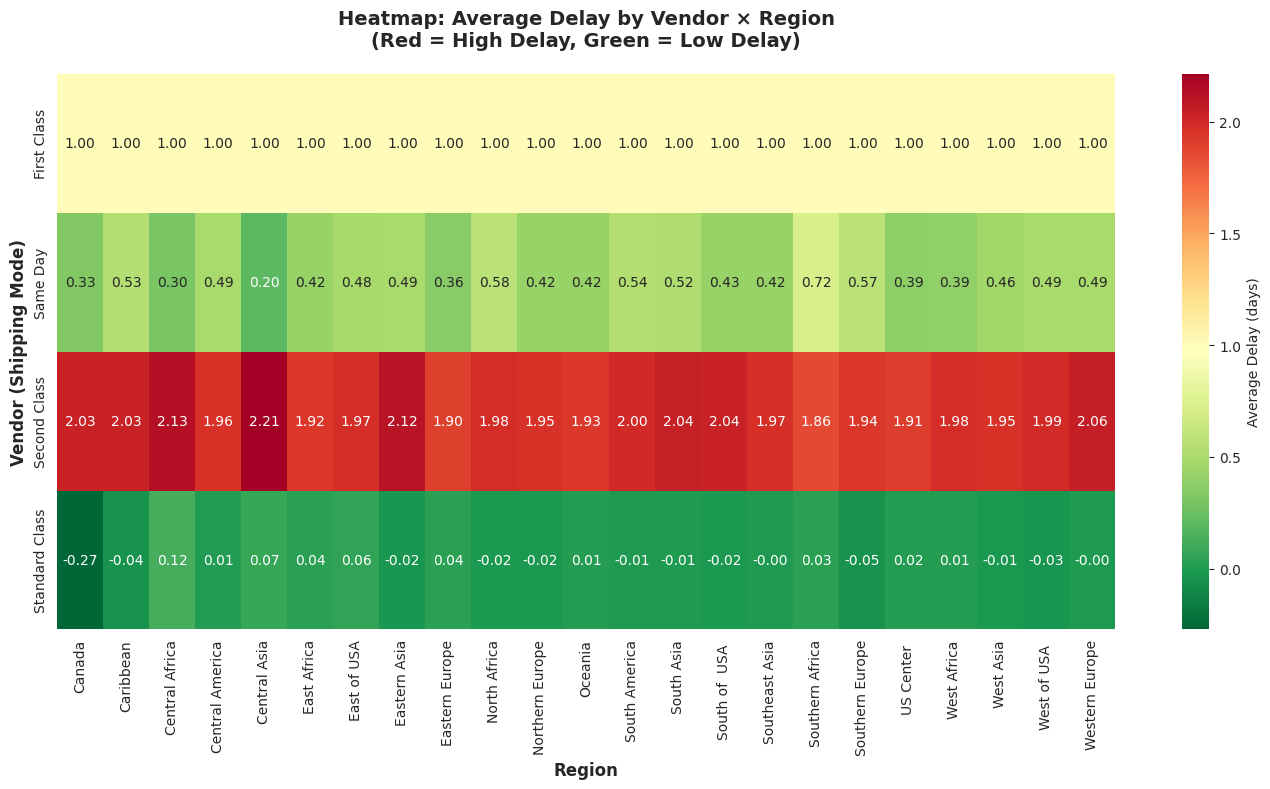

Chart saved: 02_vendor_region_heatmap.png


In [62]:
# Chart 2: Vendor vs Region Heatmap
vendor_region_matrix = df_clean.pivot_table(
    values='delay_days',
    index='Shipping Mode',
    columns='Order Region',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(vendor_region_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Average Delay (days)'}, ax=ax)
ax.set_title('Heatmap: Average Delay by Vendor × Region\n(Red = High Delay, Green = Low Delay)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Vendor (Shipping Mode)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('02_vendor_region_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 02_vendor_region_heatmap.png")

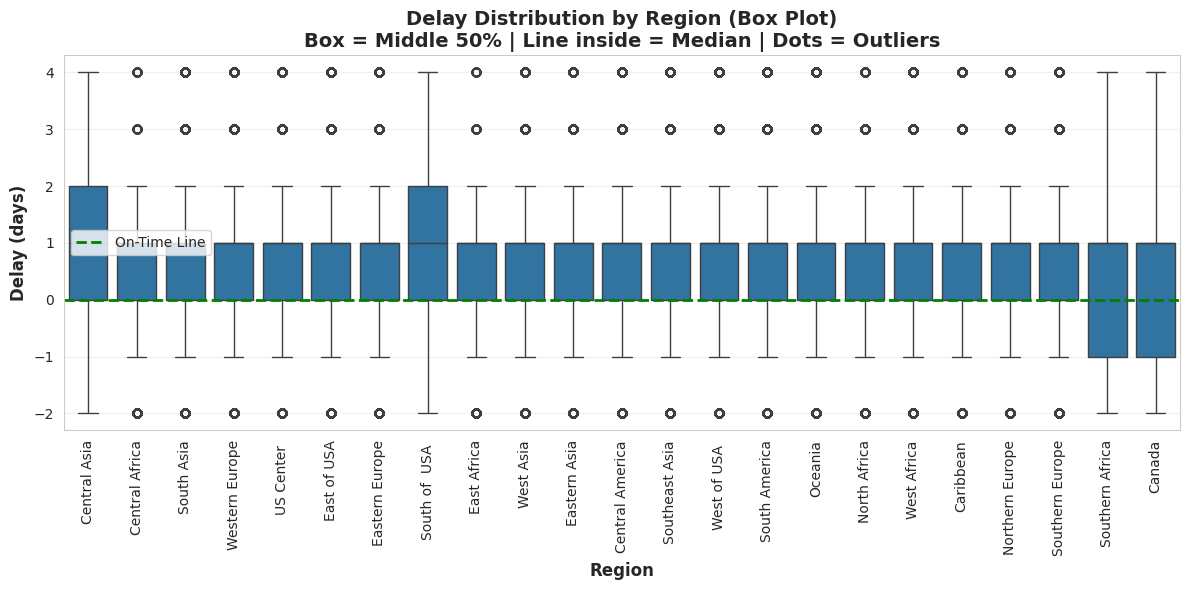

Chart saved: 03_delay_distribution_by_region.png


In [68]:
# Chart 3: Box Plot - Delay Distribution by Region
fig, ax = plt.subplots(figsize=(12, 6))

regions_sorted = region_summary.sort_values('avg_delay', ascending=False)['Order Region'].tolist()
df_plot = df_clean[df_clean['delay_days'] <= 10]  # Limit to reasonable range

sns.boxplot(data=df_plot, x='Order Region', y='delay_days', order=regions_sorted, ax=ax)
ax.axhline(y=0, color='green', linestyle='--', linewidth=2, label='On-Time Line')
ax.set_ylabel('Delay (days)', fontsize=12, fontweight='bold')
ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_title('Delay Distribution by Region (Box Plot)\nBox = Middle 50% | Line inside = Median | Dots = Outliers',
             fontsize=14, fontweight='bold')

# Set the x label in 90 rotation
plt.xticks(rotation=90)

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_delay_distribution_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 03_delay_distribution_by_region.png")

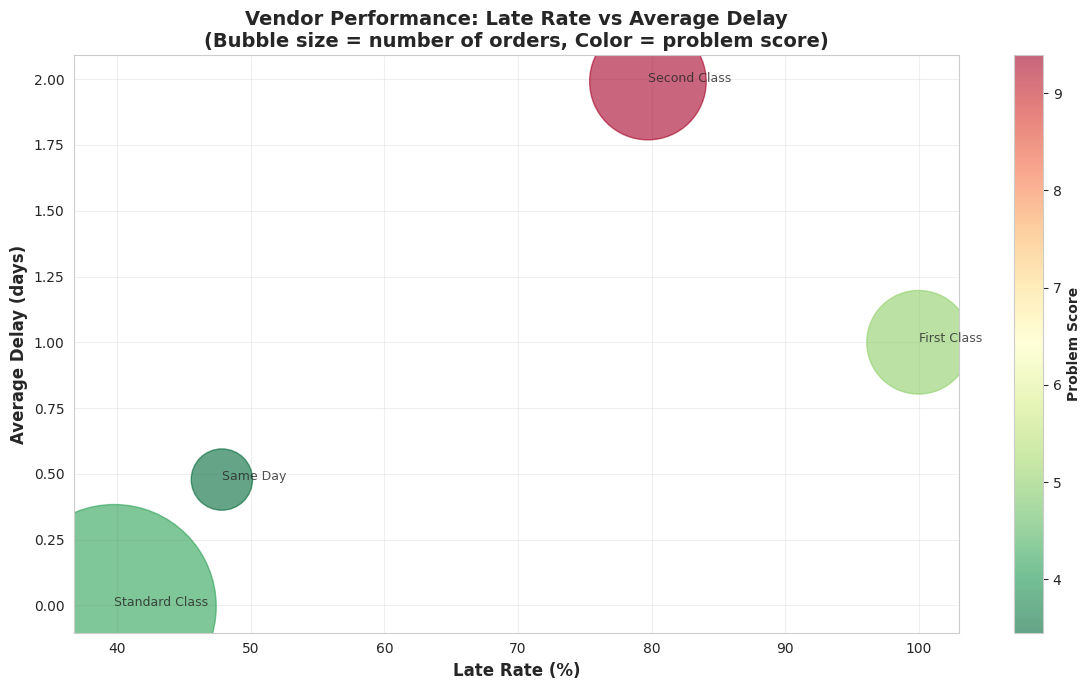

Chart saved: 04_vendor_performance_scatter.png


In [69]:
# Chart 4: Vendor Late Rate vs Average Delay (Scatter)
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(vendor_profiles['late_rate']*100, vendor_profiles['avg_delay'],
                     s=vendor_profiles['total_orders']/5, alpha=0.6,
                     c=vendor_profiles['problem_score'], cmap='RdYlGn_r')

# Add vendor labels
for idx, row in vendor_profiles.iterrows():
    ax.annotate(row['Shipping Mode'],
                (row['late_rate']*100, row['avg_delay']),
                fontsize=9, alpha=0.8)

ax.set_xlabel('Late Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Delay (days)', fontsize=12, fontweight='bold')
ax.set_title('Vendor Performance: Late Rate vs Average Delay\n(Bubble size = number of orders, Color = problem score)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Problem Score', fontweight='bold')

plt.tight_layout()
plt.savefig('04_vendor_performance_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 04_vendor_performance_scatter.png")

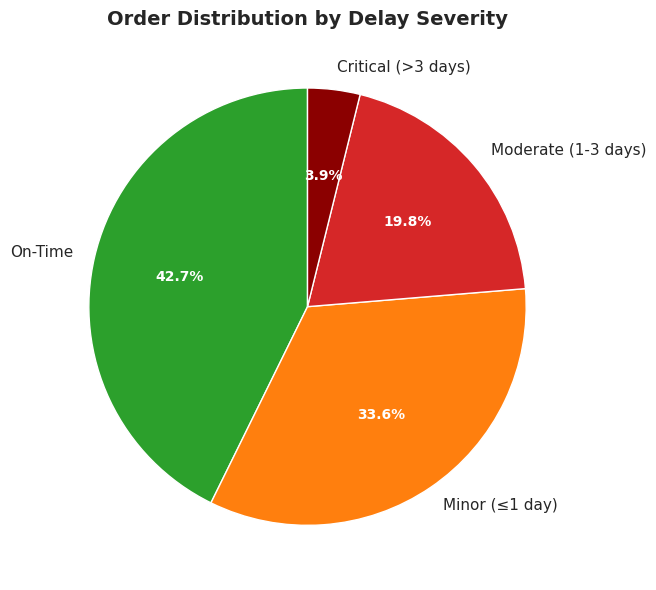

Chart saved: 05_delay_severity_distribution.png


In [70]:
# Chart 5: Delay Severity Breakdown
fig, ax = plt.subplots(figsize=(10, 6))

severity_counts = df_clean['delay_severity'].value_counts()
colors_severity = ['#2ca02c', '#ff7f0e', '#d62728', '#8b0000']

wedges, texts, autotexts = ax.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
                                    colors=colors_severity, startangle=90, textprops={'fontsize': 11})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Order Distribution by Delay Severity', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('05_delay_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 05_delay_severity_distribution.png")

In [76]:
# Export cleaned dataset


# 1. Full cleaned dataset with all metrics
# Note: Using columns confirmed to exist in the latest kernel state
df_export = df_clean[['Order Id', 'order date (DateOrders)', 'shipping date (DateOrders)',
                      'Shipping Mode', 'Order Region', 'Category Name',
                      'Days for shipping (real)', 'Days for shipment (scheduled)',
                      'delay_days', 'is_late', 'delay_severity',
                      'Late_delivery_risk', 'Sales', 'Order Profit Per Order', 'z_score']].copy()

df_export.to_csv('01_cleaned_supply_chain_data.csv', index=False)
print(f" Saved: 01_cleaned_supply_chain_data.csv ({len(df_export):,} rows)")

# 2. Vendor summary
# top_10_vendors currently has: Shipping Mode, total_orders, avg_delay, delay_std, late_rate, problem_score
vendor_export = top_10_vendors[['Shipping Mode', 'total_orders', 'avg_delay',
                                'delay_std', 'late_rate', 'problem_score']].copy()
vendor_export.to_csv('02_top_10_problem_vendors.csv', index=False)
print(f" Saved: 02_top_10_problem_vendors.csv")

# 3. Regional summary
region_export = region_summary[['Order Region', 'total_orders', 'avg_delay', 'median_delay',
                               'delay_std', 'late_orders', 'late_rate']].copy()
region_export.to_csv('03_regional_summary.csv', index=False)
print(f" Saved: 03_regional_summary.csv")

# 4. Category summary
category_export = category_summary[['Category Name', 'total_orders', 'avg_delay', 'median_delay',
                                    'delay_std', 'late_orders', 'late_rate']].copy()
category_export.to_csv('04_category_summary.csv', index=False)
print(f" Saved: 04_category_summary.csv")



 Saved: 01_cleaned_supply_chain_data.csv (180,519 rows)
 Saved: 02_top_10_problem_vendors.csv
 Saved: 03_regional_summary.csv
 Saved: 04_category_summary.csv
